In [3]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from tqdm import tqdm
import os
from dataclasses import astuple, asdict
from global_variables import *

In [11]:
import json

nz = 256
nx = 256
batch_size = 7

bf_ids = [0, 1]
resampler_id = 2
apod_id = 4
bf_names = ["DAS", "MVB"]

metadata = {
    "batch_size": batch_size,
    "bf_ids": bf_ids,
    "apod_id": apod_id,
    "resampler_id": resampler_id
}

metadata_str = json.dumps(metadata)

def transform(pw, eps=1e-8):
    rf_max = pw.data / np.max(np.abs(pw.data))
    sigma = np.std(rf_max) + eps
    pw.data = rf_max / sigma
    return pw

In [5]:
from deep_bf.wrapper.bench.fast_bench import FastBench

name = "contrast_speckle_simu_dataset_rf"
name = "carotid_cross_expe_dataset_rf"
name = "TSH024"

for _ in range(5):
    pw = DL.get_defined_pwdata(name, "RF")
    pw = transform(pw)
    bench = FastBench(pw, nz, nx, bf_ids, resampler_id, apod_id, batch_size)
    output = bench()

In [12]:
import h5py
import hdf5plugin
import numpy as np

import json
from tqdm import tqdm
from deep_bf.wrapper.bench.fast_bench import FastBench
from deep_bf.config_registery.path_center import PathCenter

from dataclasses import asdict

pc = PathCenter(is_server=False)
dataset_paths = pc.get_dataset_paths()

df = DL.get_df()
query = "(RF == 1) and (nc == 128) and (name.str.slice(0, 3) != 'JHU')"
df = df.query(query)

names = df["name"]
pbar = tqdm(names)

for name in pbar:
    pbar.set_description(f"Procesando archivo: {name}°")

    pw = DL.get_defined_pwdata(name, "RF")
    pw = transform(pw)

    bench = FastBench(pw, nz, nx, bf_ids, resampler_id, apod_id, batch_size)
    output = bench()
    
    angle = pw.n_angles // 2
    rf = pw.data[angle]

    rf_transform = "sharifzadeh"

    path = Path(f"{dataset_paths.raw}/{name}.hdf5")

    with h5py.File(path, "a") as f:
        g = f.require_group(rf_transform)
        #g.create_dataset("rf", data=rf, chunks=True, **hdf5plugin.Bitshuffle(nelems=0, cname="zstd"))
        #g.create_dataset('metadata', data=metadata_str, dtype=h5py.string_dtype(encoding='utf-8'))

        for bf_name in bf_names:
            g2 = g.require_group(f"{nz}/{bf_name}")

            _o = output[bf_name]
            times = asdict(_o.times)
            times_str = json.dumps(times)

            gt = _o.data
            gt_central = gt[angle]
            gt_sum = np.sum(gt, axis=0)
            gt_mean = np.mean(gt, axis=0)

            g2.create_dataset('times', data=times_str, dtype=h5py.string_dtype(encoding='utf-8'))
            g2.create_dataset("ground_truth_central", data=gt_central, chunks=True, **hdf5plugin.Bitshuffle(nelems=0, cname="zstd"))
            g2.create_dataset("ground_truth_sum", data=gt_sum, chunks=True, **hdf5plugin.Bitshuffle(nelems=0, cname="zstd"))
            g2.create_dataset("ground_truth_mean", data=gt_mean, chunks=True, **hdf5plugin.Bitshuffle(nelems=0, cname="zstd"))


Procesando archivo: MYO001°:   0%|          | 0/550 [00:00<?, ?it/s]

Procesando archivo: resolution_distorsion_simu_dataset_rf°: 100%|██████████| 550/550 [04:27<00:00,  2.05it/s]


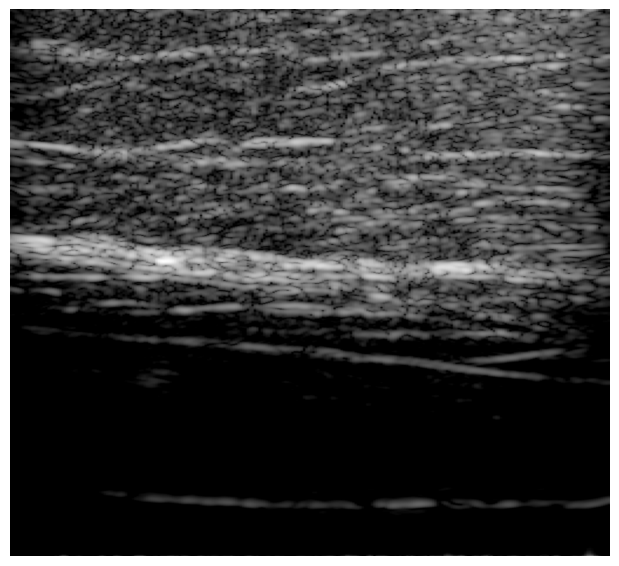

In [26]:
import matplotlib.pyplot as plt
from deep_bf.beamformers import get_rf_bmode

bf_name = "DAS"
#bf_name = "MVB"

vmin = -60
vmax = 0
_o = output[bf_name]

#b_mode = _o.get_bmode(mean=True, vmin=vmin, vmax=vmax)
b_mode = _o.get_bmode(mean=False, vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(6, 8), frameon=False)
ax = fig.add_axes([0, 0, 1, 1])

extent = (_o.xlims[0], _o.xlims[-1], _o.zlims[-1], _o.zlims[0])

ax.imshow(b_mode, cmap='gray', vmin=vmin, vmax=vmax,
          extent=extent,
          aspect='equal')
ax.set_axis_off()
plt.show()

In [10]:
from deep_bf.wrapper.bench.beamfomer_builder import Bench

name = "contrast_speckle_simu_dataset_rf"

nz = 2048
nx = 256
batch_size = 8

bf_group_names = ["das", "mvb"]
bf_names = ["DASSimple", "MVBSimple"]

pw = DL.get_defined_pwdata(name, "RF")
pw = transform(pw)


bench = Bench(pw, nz, nx, batch_size)
output = bench()

In [12]:
import h5py
import hdf5plugin

import json
from tqdm import tqdm
from deep_bf.wrapper.bench.beamfomer_builder import Bench

df = DL.get_df()
query = "(RF == 1) and (nc == 128) and (name.str.slice(0, 3) != 'JHU')"
df = df.query(query)

names = df["name"]
#names = names[23:25]

#names = ["TSH023", "TSH324"]

pbar = tqdm(names)

nz = 1024
nx = 256
batch_size = 8

bf_group_names = ["das", "mvb"]
bf_names = ["DASSimple", "MVBSimple"]

for name in pbar:
    pbar.set_description(f"Procesando archivo: {name}°")

    pw = DL.get_defined_pwdata(name, "RF")
    pw = transform(pw)

    bench = Bench(pw, nz, nx, batch_size)
    output = bench()
    
    angle = pw.n_angles // 2
    rf = pw.data[angle]

    rf_transform = "sharifzadeh"

    path = Path(f"{dataset_paths.raw}/{name}.hdf5")

    with h5py.File(path, "a") as f:
        g = f.require_group(f"{rf_transform}/{nz}")
        #g.create_dataset("rf", data=rf, chunks=True, **hdf5plugin.Bitshuffle(nelems=0, cname="zstd"))

        for bf_name, bf_group_name in zip(bf_names, bf_group_names):
            g2 = g.require_group(bf_group_name)

            _output = output[bf_name]

            metadata = _output["times"]
            metadata["batch_size"] = batch_size
            metadata_str = json.dumps(metadata)

            gt = _output["out"]
            gt_central = gt[angle]
            gt_sum = gt.sum(axis=0).cpu()
            gt_mean = gt.mean(axis=0).cpu()

            g2.create_dataset('metadata', data=metadata_str, dtype=h5py.string_dtype(encoding='utf-8'))

            g2.create_dataset("ground_truth_central", data=gt_central, chunks=True, **hdf5plugin.Bitshuffle(nelems=0, cname="zstd"))
            g2.create_dataset("ground_truth_sum", data=gt_sum, chunks=True, **hdf5plugin.Bitshuffle(nelems=0, cname="zstd"))
            g2.create_dataset("ground_truth_mean", data=gt_mean, chunks=True, **hdf5plugin.Bitshuffle(nelems=0, cname="zstd"))



Procesando archivo: resolution_distorsion_simu_dataset_rf°: 100%|██████████| 550/550 [05:54<00:00,  1.55it/s]


In [11]:
#bf_name = "MVBSimple"
bf_name = "DASSimple"


o = output[bf_name]["times"]

print(o)
time = o["meshgrid"] + o["d_rx"] + o["apod"] + sum(o["batch_gsi"]) + sum(o["batch_sampler"]) + sum(o["batch_bf"])
print(time)

{'meshgrid': 0.00015568899834761396, 'd_rx': 0.003052062998904148, 'apod': 0.010010404999775346, 'batch_gsi': [0.03205481199984206, 0.030627870000898838, 0.030166942997311708, 0.02680748100101482], 'batch_sampler': [0.05456656700334861, 0.05415668899877346, 0.05480960499698995, 0.04701905900219572], 'batch_bf': [0.013170426002034219, 0.013302244999067625, 0.013070226999843726, 0.012375111000437755]}
0.3953451919987856


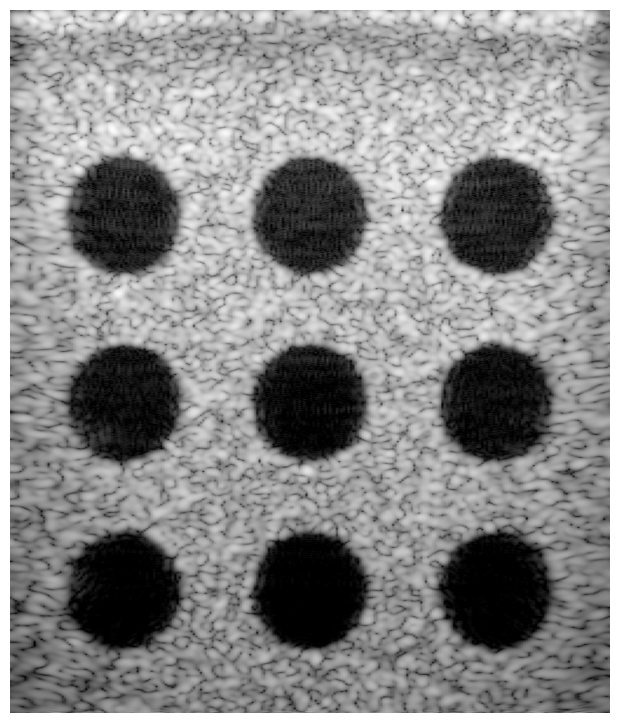

In [7]:
import matplotlib.pyplot as plt
from deep_bf.beamformers import get_rf_bmode, compute_meshgrid

#bf_name = "MVBSimple"
bf_name = "DASSimple"

Z, X = compute_meshgrid(pw, nz, nx)
Z = Z.cpu()
X = X.cpu()

#output = das[0].cpu().numpy()
data = output[bf_name]["out"].mean(axis=0).cpu().numpy()

zlims = np.array([Z[0, 0], Z[-1, 0]]) * 1e3
xlims = np.array([X[0, 0], X[0, -1]]) * 1e3

vmin = -60
vmax = 0

fig = plt.figure(figsize=(6, 8), frameon=False)
ax = fig.add_axes([0, 0, 1, 1])

b_mode = get_rf_bmode(data, vmin, vmax)
#b_mode = get_rf_bmode(gt, vmin, vmax)

extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])

ax.imshow(b_mode, cmap='gray', vmin=vmin, vmax=vmax,
          extent=extent,
          aspect='equal')
ax.set_axis_off()
plt.show()

In [13]:
from deep_bf.dataset import GlobalSamplesIdx
from deep_bf.beamformers.das import DAS
from deep_bf.beamformers.mv import MVB
from deep_bf.beamformers.utils.sampler import GridSampler, SamplerById, SamplerSimple
from deep_bf.beamformers import compute_meshgrid, dynamic_receive_aperture, compute_d_rx

import h5py
import hdf5plugin

#name = "contrast_speckle_expe_dataset_rf"
#name = "carotid_cross_expe_dataset_rf"
#name = "carotid_long_expe_dataset_rf"

name = "contrast_speckle_simu_dataset_rf"
#name = "MYO001"

#name = "TSH204"
#name = "UFL004"

gs = GridSampler()

nz = 2048
nx = 256

query = f"name == '{name}'"
batch_size = 10
pw = DL.get_defined_pwdata(name, "RF")

Z, X = compute_meshgrid(pw, nz, nx)
d_rx = compute_d_rx(pw, Z, X)
apod = dynamic_receive_aperture(Z, X, pw.probe_geometry, 1.75, "tukey25").to("cuda")

das = torch.zeros(pw.n_angles, nz, nx)
mv = torch.zeros(pw.n_angles, nz, nx)

for s in range(0, pw.n_angles, batch_size):
    e = min(s + batch_size, pw.n_angles)
    angles = np.arange(s, e)
    #angles = pw.angles[s:e]
    n_angles = len(angles)

    # TODO: En compute_samples_idx_by_angles ver si es necesario sacar r_dx segun angles o no.
    gsi = GlobalSamplesIdx(dataset_paths.samples_idx, query, is_train=False, n_angles=n_angles)
    gsi.set_samples_idx_by_pw(pw, Z, X, d_rx, angles)
    #print(gsi.samples_idx.shape)

    rfs = torch.from_numpy(pw.data[s:e]).to("cuda")
    ids = torch.from_numpy(gsi[name]).to("cuda")
    #print("rfs: ", rfs.shape, "ids: ", ids.shape)
    
    sampler = SamplerById(gsi, gs, batch_size)
    #sampler = SamplerSimple(gsi, gs, batch_size)

    bf1 = DAS(nz, nx, sampler).to("cuda").eval()
    bf2 = MVB(nz, nx, sampler, batch_size=1, z_chunk=nz, nc=128).to("cuda").eval()

    with torch.no_grad():
        o = bf1(rfs, ids, apod)
        das[s:e] = o

        o2 = bf2(rfs, ids, apod)
        mv[s:e] = o2
    

In [5]:
from deep_bf.dataset import GlobalSamplesIdx
from deep_bf.beamformers.das import DASSimple
from deep_bf.beamformers.mv import MVBSimple
from deep_bf.beamformers.utils.sampler import GridSampler, SamplerById, SamplerSimple
from deep_bf.beamformers import compute_meshgrid, dynamic_receive_aperture, compute_d_rx

import h5py
import hdf5plugin

#name = "contrast_speckle_expe_dataset_rf"
#name = "carotid_cross_expe_dataset_rf"
#name = "carotid_long_expe_dataset_rf"

name = "contrast_speckle_simu_dataset_rf"
#name = "MYO001"

#name = "TSH204"
#name = "UFL004"

gs = GridSampler()

nz = 2048
nx = 256

query = f"name == '{name}'"
batch_size = 8
pw = DL.get_defined_pwdata(name, "RF")

Z, X = compute_meshgrid(pw, nz, nx)
d_rx = compute_d_rx(pw, Z, X)
apod = dynamic_receive_aperture(Z, X, pw.probe_geometry, 1.75, "tukey25").to("cuda")

das = torch.zeros(pw.n_angles, nz, nx)
mv = torch.zeros(pw.n_angles, nz, nx)

for s in range(0, pw.n_angles, batch_size):
    e = min(s + batch_size, pw.n_angles)
    angles = np.arange(s, e)
    #angles = pw.angles[s:e]
    n_angles = len(angles)

    # TODO: En compute_samples_idx_by_angles ver si es necesario sacar r_dx segun angles o no.
    gsi = GlobalSamplesIdx(dataset_paths.samples_idx, query, is_train=False, n_angles=n_angles)
    gsi.set_samples_idx_by_pw(pw, Z, X, d_rx, angles)
    #print(gsi.samples_idx.shape)

    rfs = torch.from_numpy(pw.data[s:e]).to("cuda")
    ids = torch.from_numpy(gsi[name]).to("cuda")
    #print("rfs: ", rfs.shape, "ids: ", ids.shape)
    
    #sampler = SamplerById(gsi, gs, batch_size)
    sampler = SamplerSimple(gsi, gs, batch_size)
    sampled_data = sampler(rfs, ids)

    bf1 = DASSimple(nz, nx).to("cuda").eval()
    bf2 = MVBSimple(nz, nx, batch_size=1, z_chunk=nz, nc=128).to("cuda").eval()

    with torch.no_grad():
        o1 = bf1(sampled_data, apod)
        das[s:e] = o1


        o2 = bf2(sampled_data, apod)
        mv[s:e] = o2
    #print(o.shape)
    

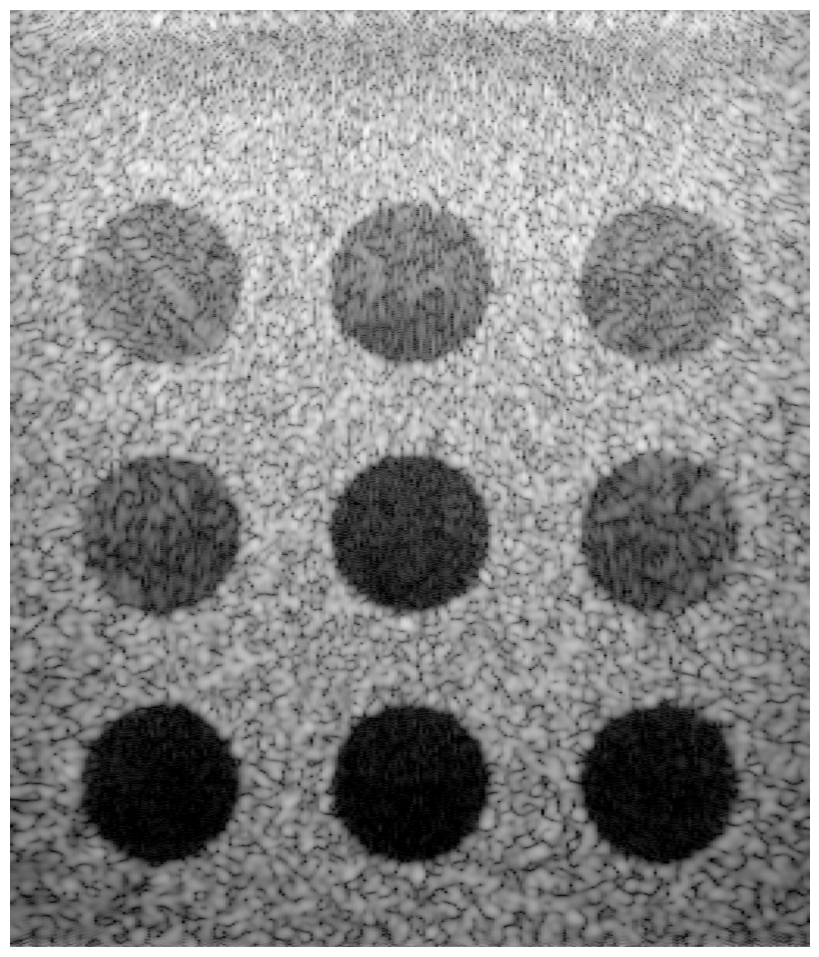

In [4]:
import matplotlib.pyplot as plt
from deep_bf.beamformers import get_rf_bmode

Z = Z.cpu()
X = X.cpu()

#output = das[0].cpu().numpy()
output = das.mean(axis=0).cpu().numpy()

zlims = np.array([Z[0, 0], Z[-1, 0]]) * 1e3
xlims = np.array([X[0, 0], X[0, -1]]) * 1e3

vmin = -60
vmax = 0

fig = plt.figure(figsize=(8, 10), frameon=False)
ax = fig.add_axes([0, 0, 1, 1])

b_mode = get_rf_bmode(output, vmin, vmax)
#b_mode = get_rf_bmode(gt, vmin, vmax)

extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])

ax.imshow(b_mode, cmap='gray', vmin=vmin, vmax=vmax,
          extent=extent,
          aspect='equal')
ax.set_axis_off()
plt.show()